# Study 1 Analyses

Code to generate the figures for study 1.

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['ytick.left'] = True
sns.set_style("ticks")

import helpers
import regression_utils
import qualitative_utils

## Generate Categories Barplot

In [3]:
significance = helpers.compute_significance_from_logprob()
annotations = {}
for (dataset, feat), res in significance.items():
    annotations[(dataset, feat)] = helpers.p_to_stars(res['p_adj'])

/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Participant", grouping, "Featurizer"], as_index=False)[ycol]
/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:217: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df_participant_level.pivot_table(


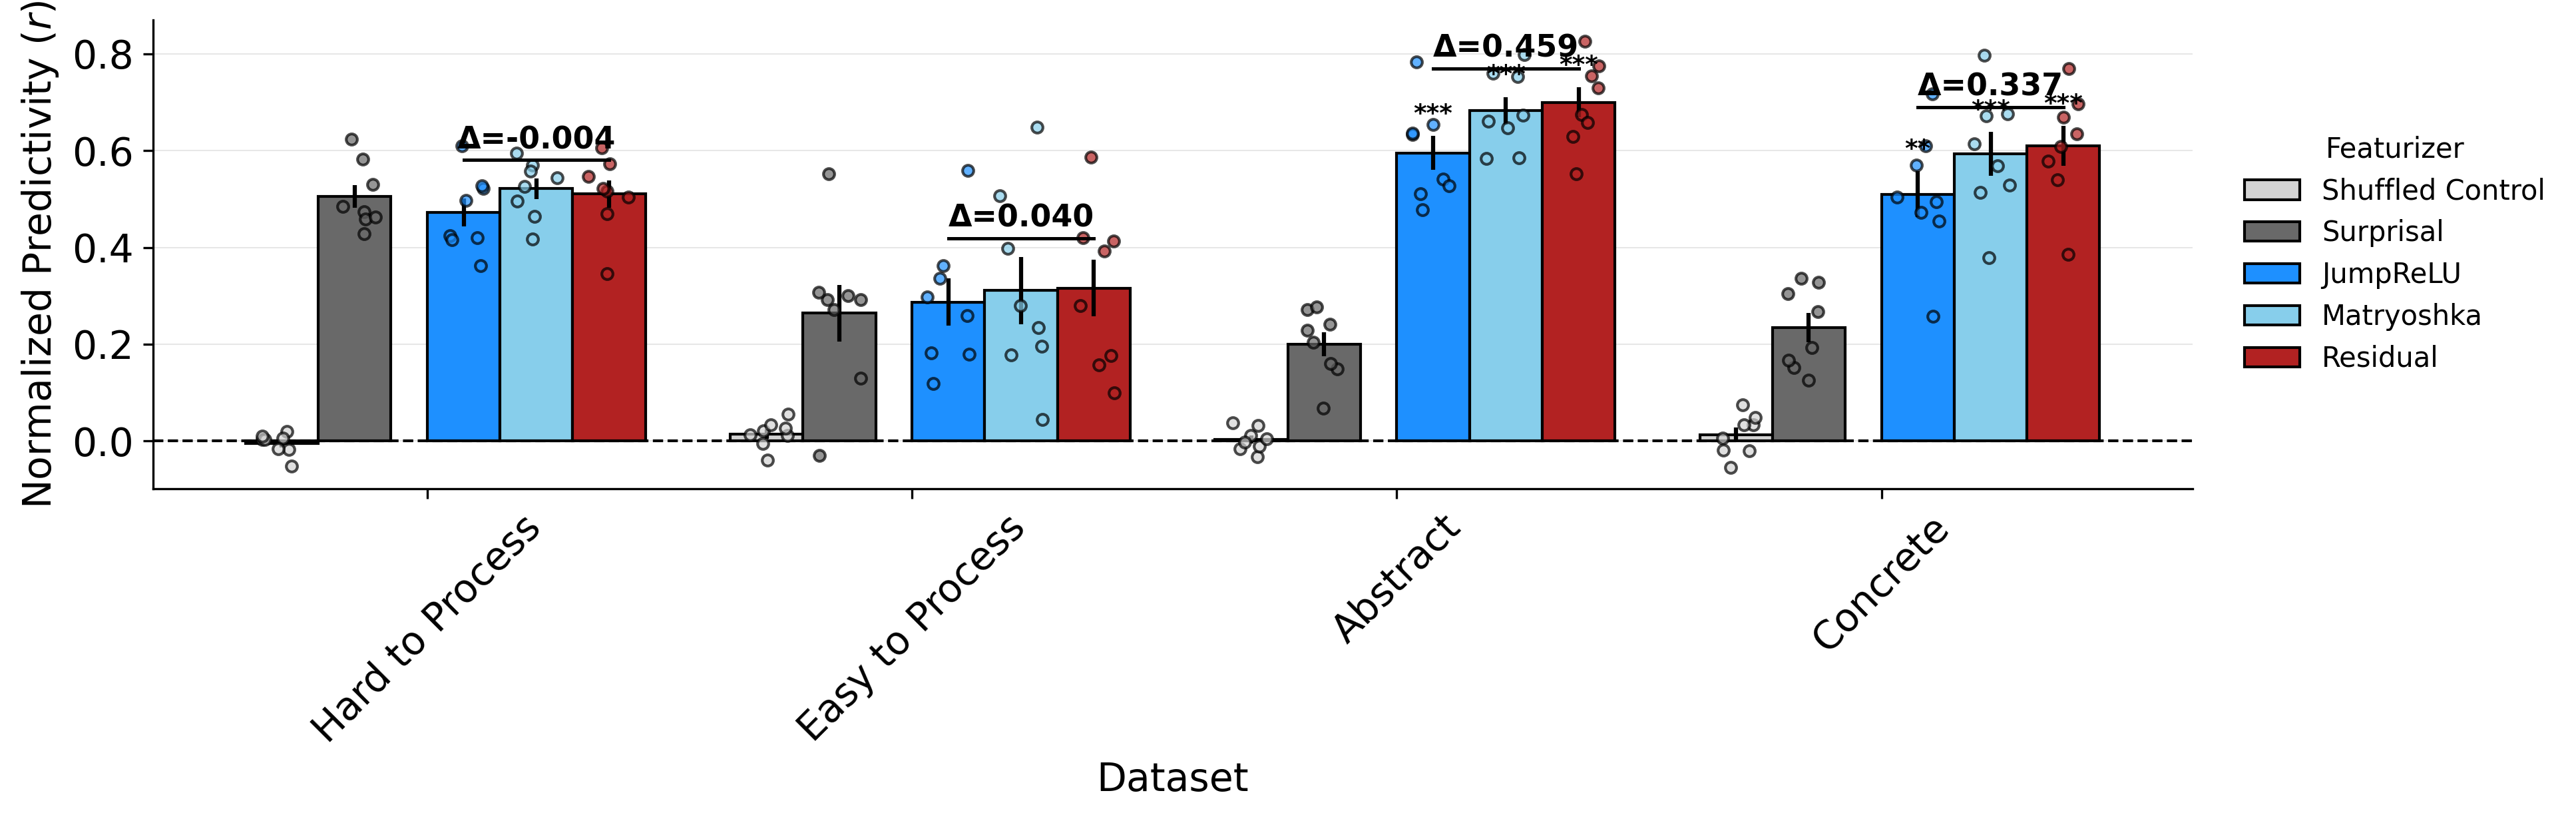

In [4]:
fig, ax = regression_utils.predictivity_bar_plot(add_significance=True, significance_annotations=annotations, filter_set=["Hard to Process", "Easy to Process", "Abstract", "Concrete"])
fig.savefig("figures/preprint/study1_categories_barplot.pdf", bbox_inches="tight")

Normalized Predictivity (r)

## Generate Qualitative Feature Analyses for Matryoshka

In [3]:
path_to_results = os.path.join("..", "results", "categories", "full_features", "regressions", "sae", "gemma-2-2b-res-matryoshka-dc", "mean", "12", "standardized_betas", "regressions", "qualitative", "Qualitative_Analysis_8000_n20_per_participant.csv")
raw_feature_sharing_stats = qualitative_utils.analyze_raw_feature_sharing(path_to_results)

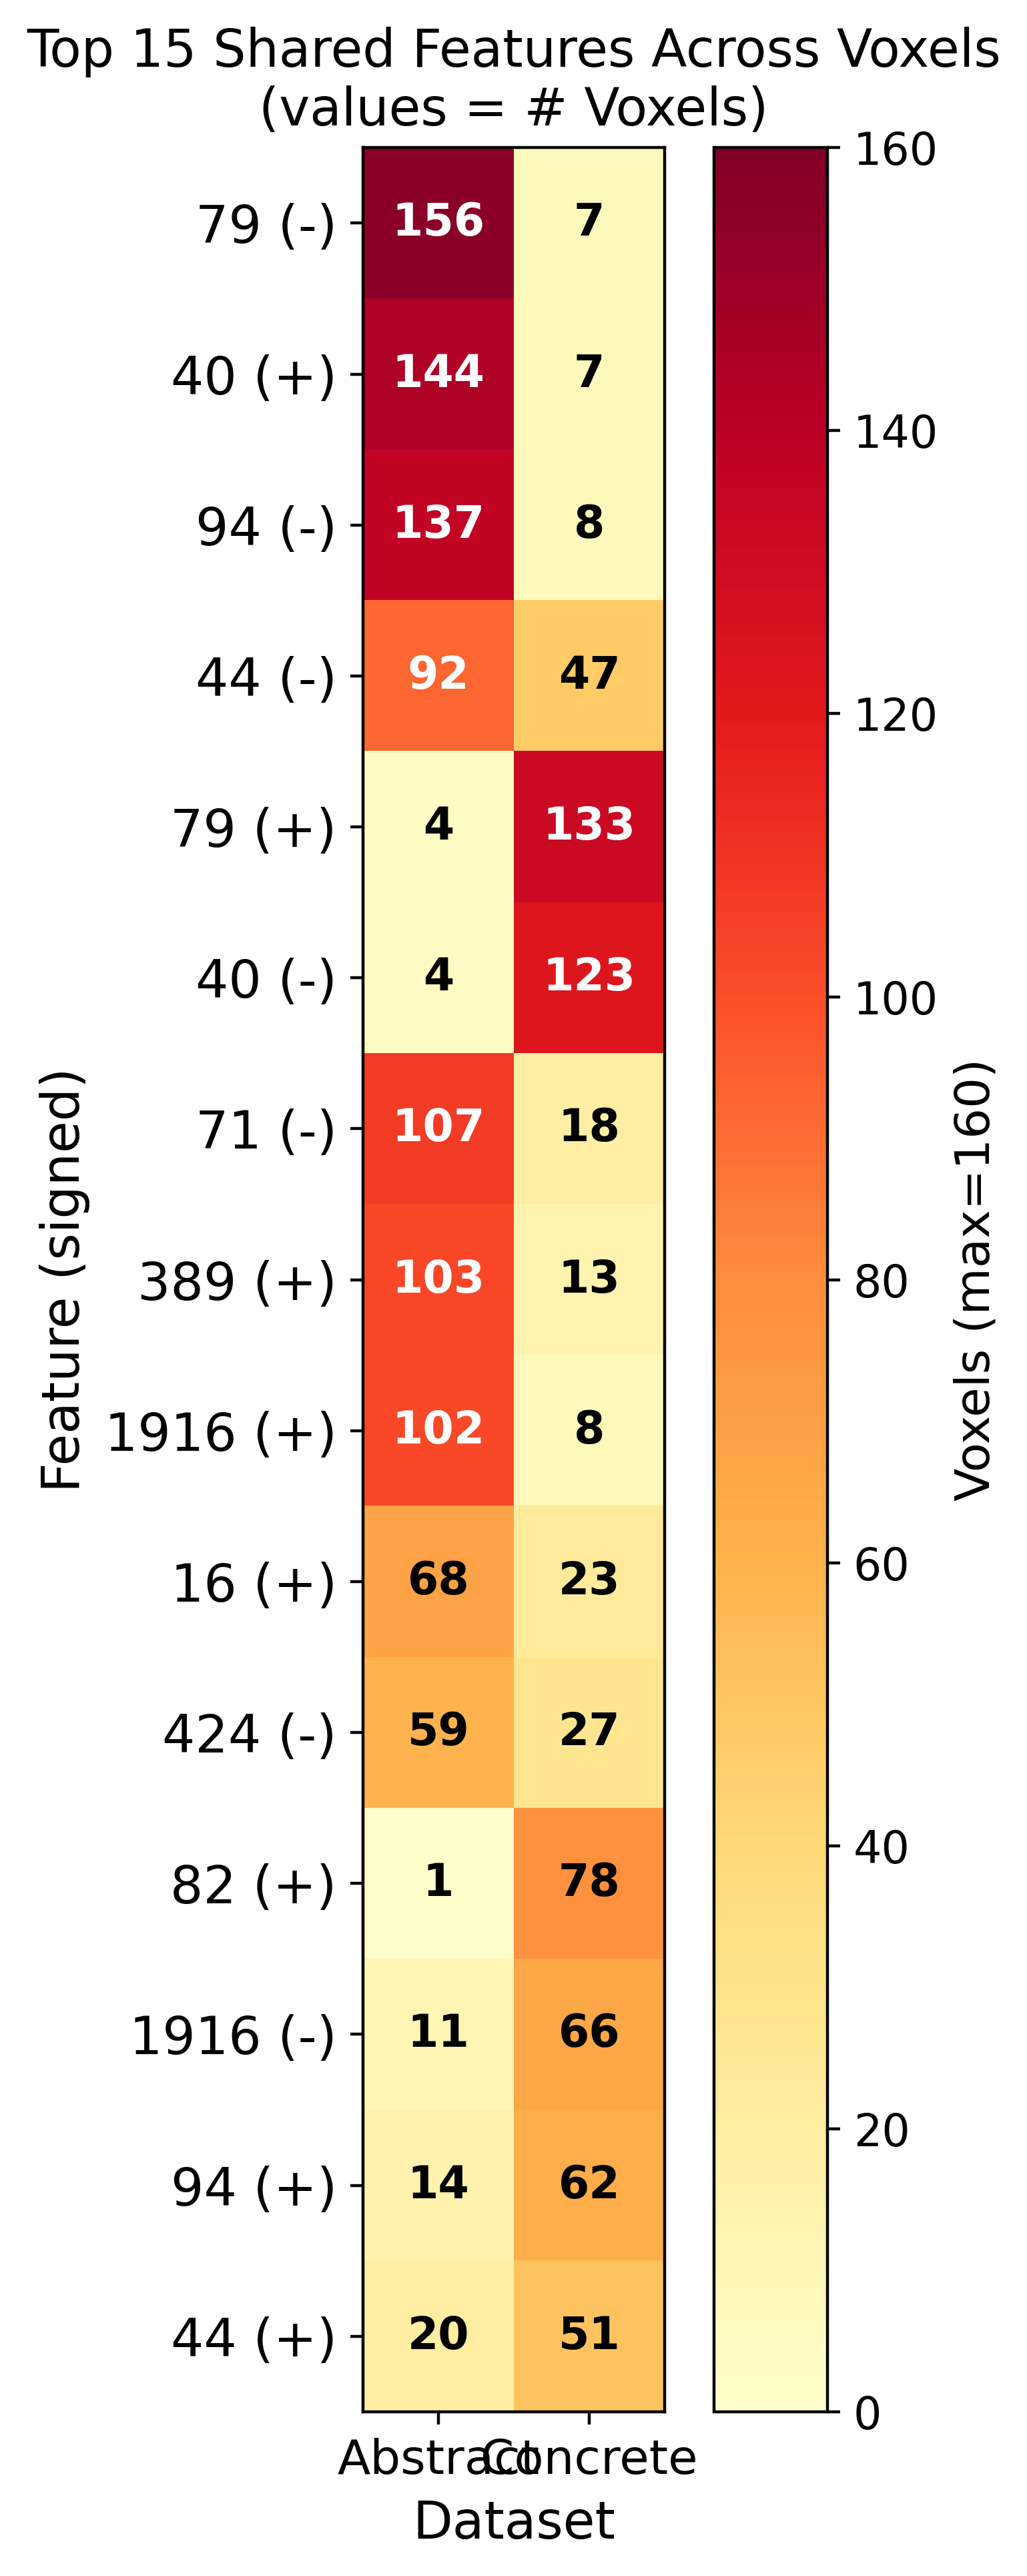

In [ ]:
fig, ax = qualitative_utils.plot_top_features_heatmap(raw_feature_sharing_stats, 160)
fig.savefig("figures/preprint/study1_categories_heatmap.pdf", bbox_inches="tight")

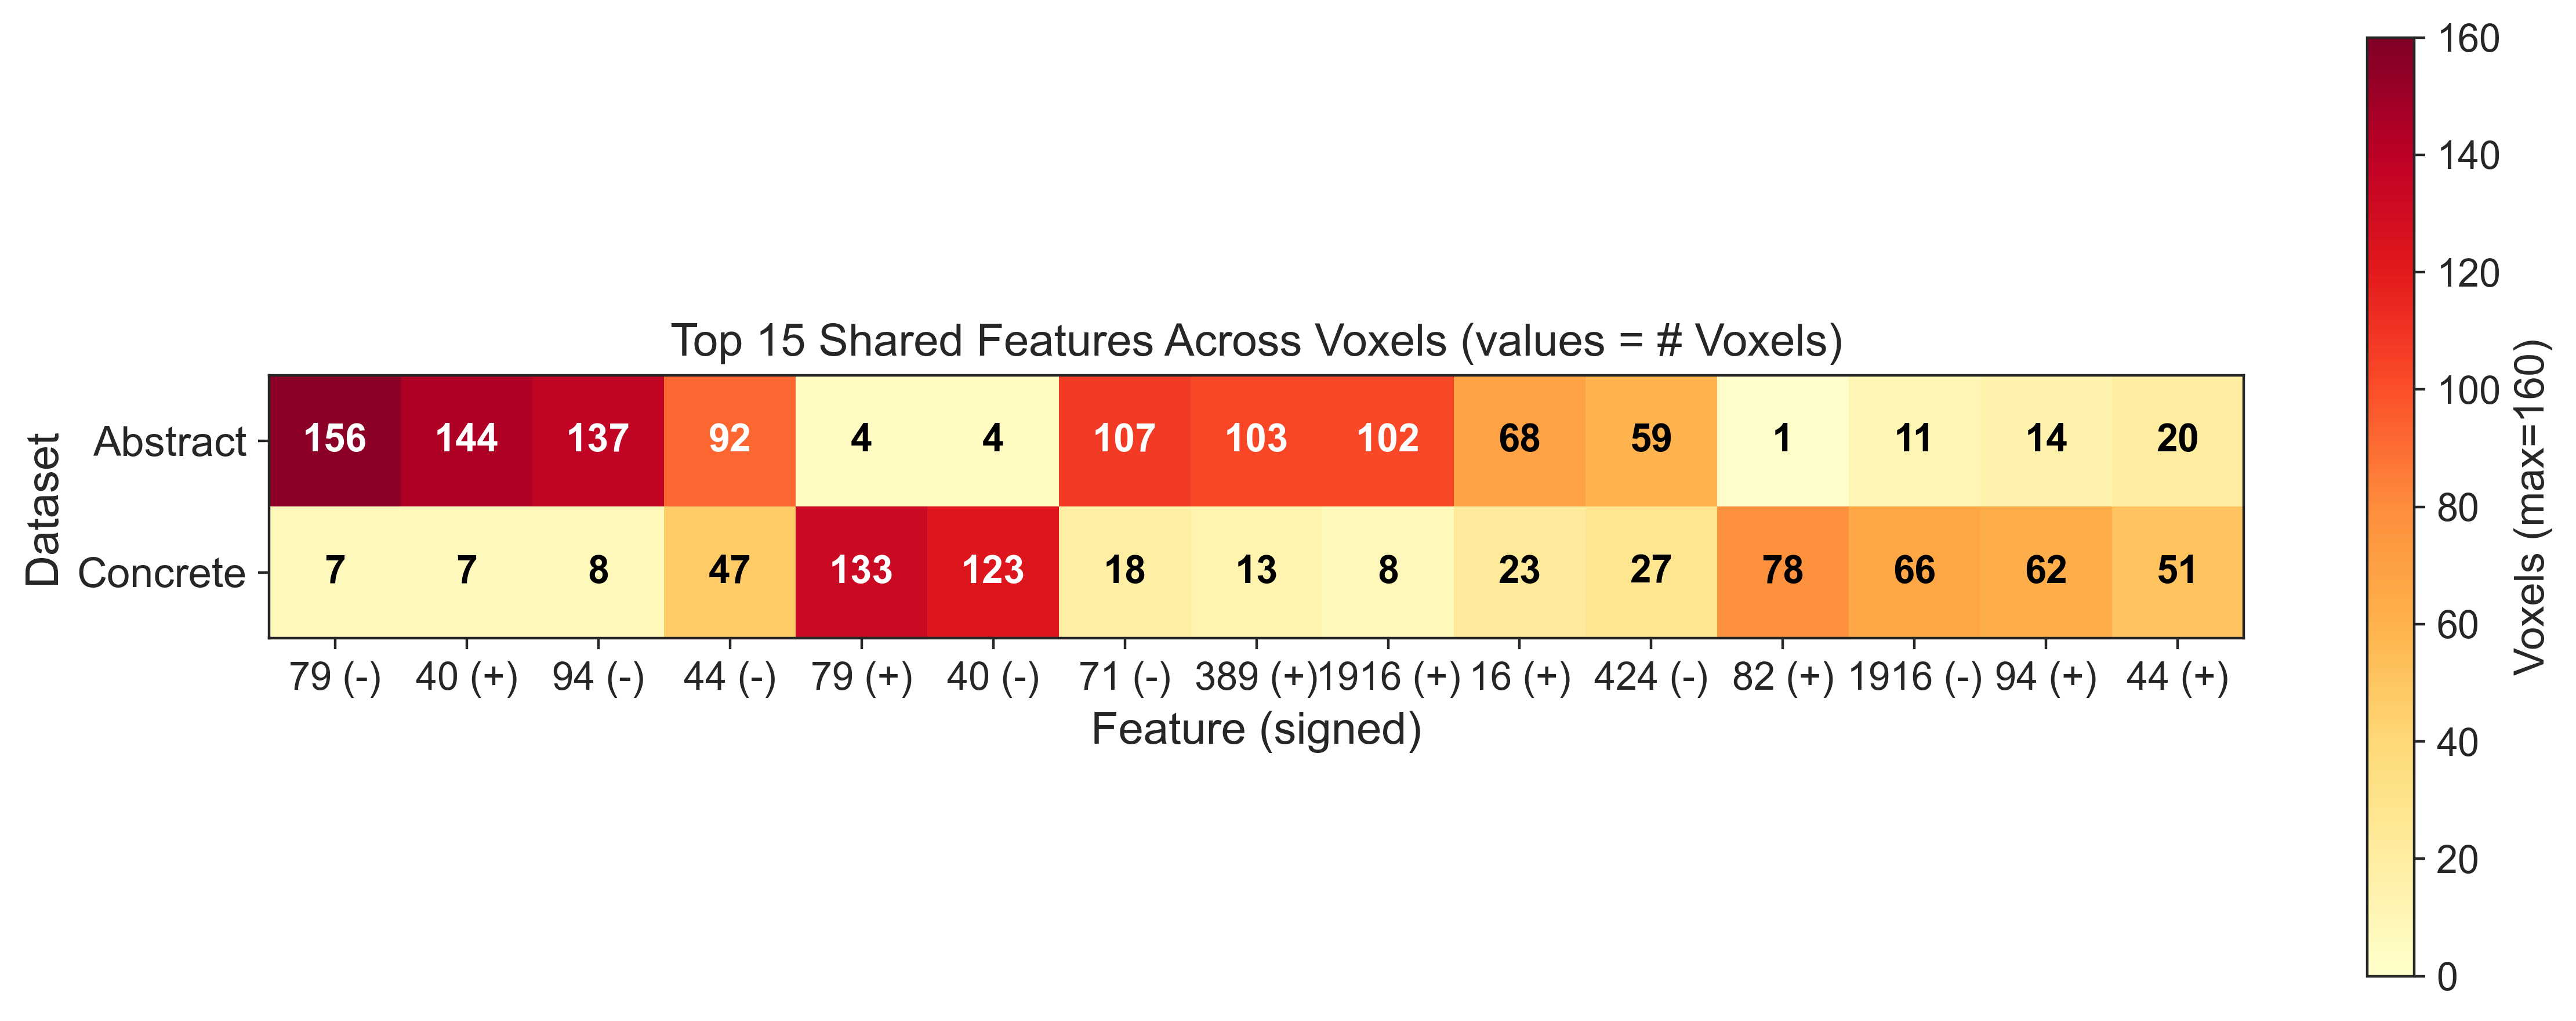

In [4]:
fig, ax = qualitative_utils.plot_top_features_heatmap(raw_feature_sharing_stats, 160, format="landscape")
fig.savefig("figures/preprint/study1_categories_heatmap_landscape.pdf", bbox_inches="tight")fig.savefig("figures/preprint/study1_categories_heatmap_landscape.svg", bbox_inches="tight")

## Appendix: Support Set Size in Categories


Overall voxel-level average Matryoshka Feature Mean: 17.669


/oscar/data/epavlick/mlepori/projects/Neuroscope/analysis/regression_utils.py:545: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Participant", group_col, "Featurizer"], as_index=False)["Feature Mean"].mean()


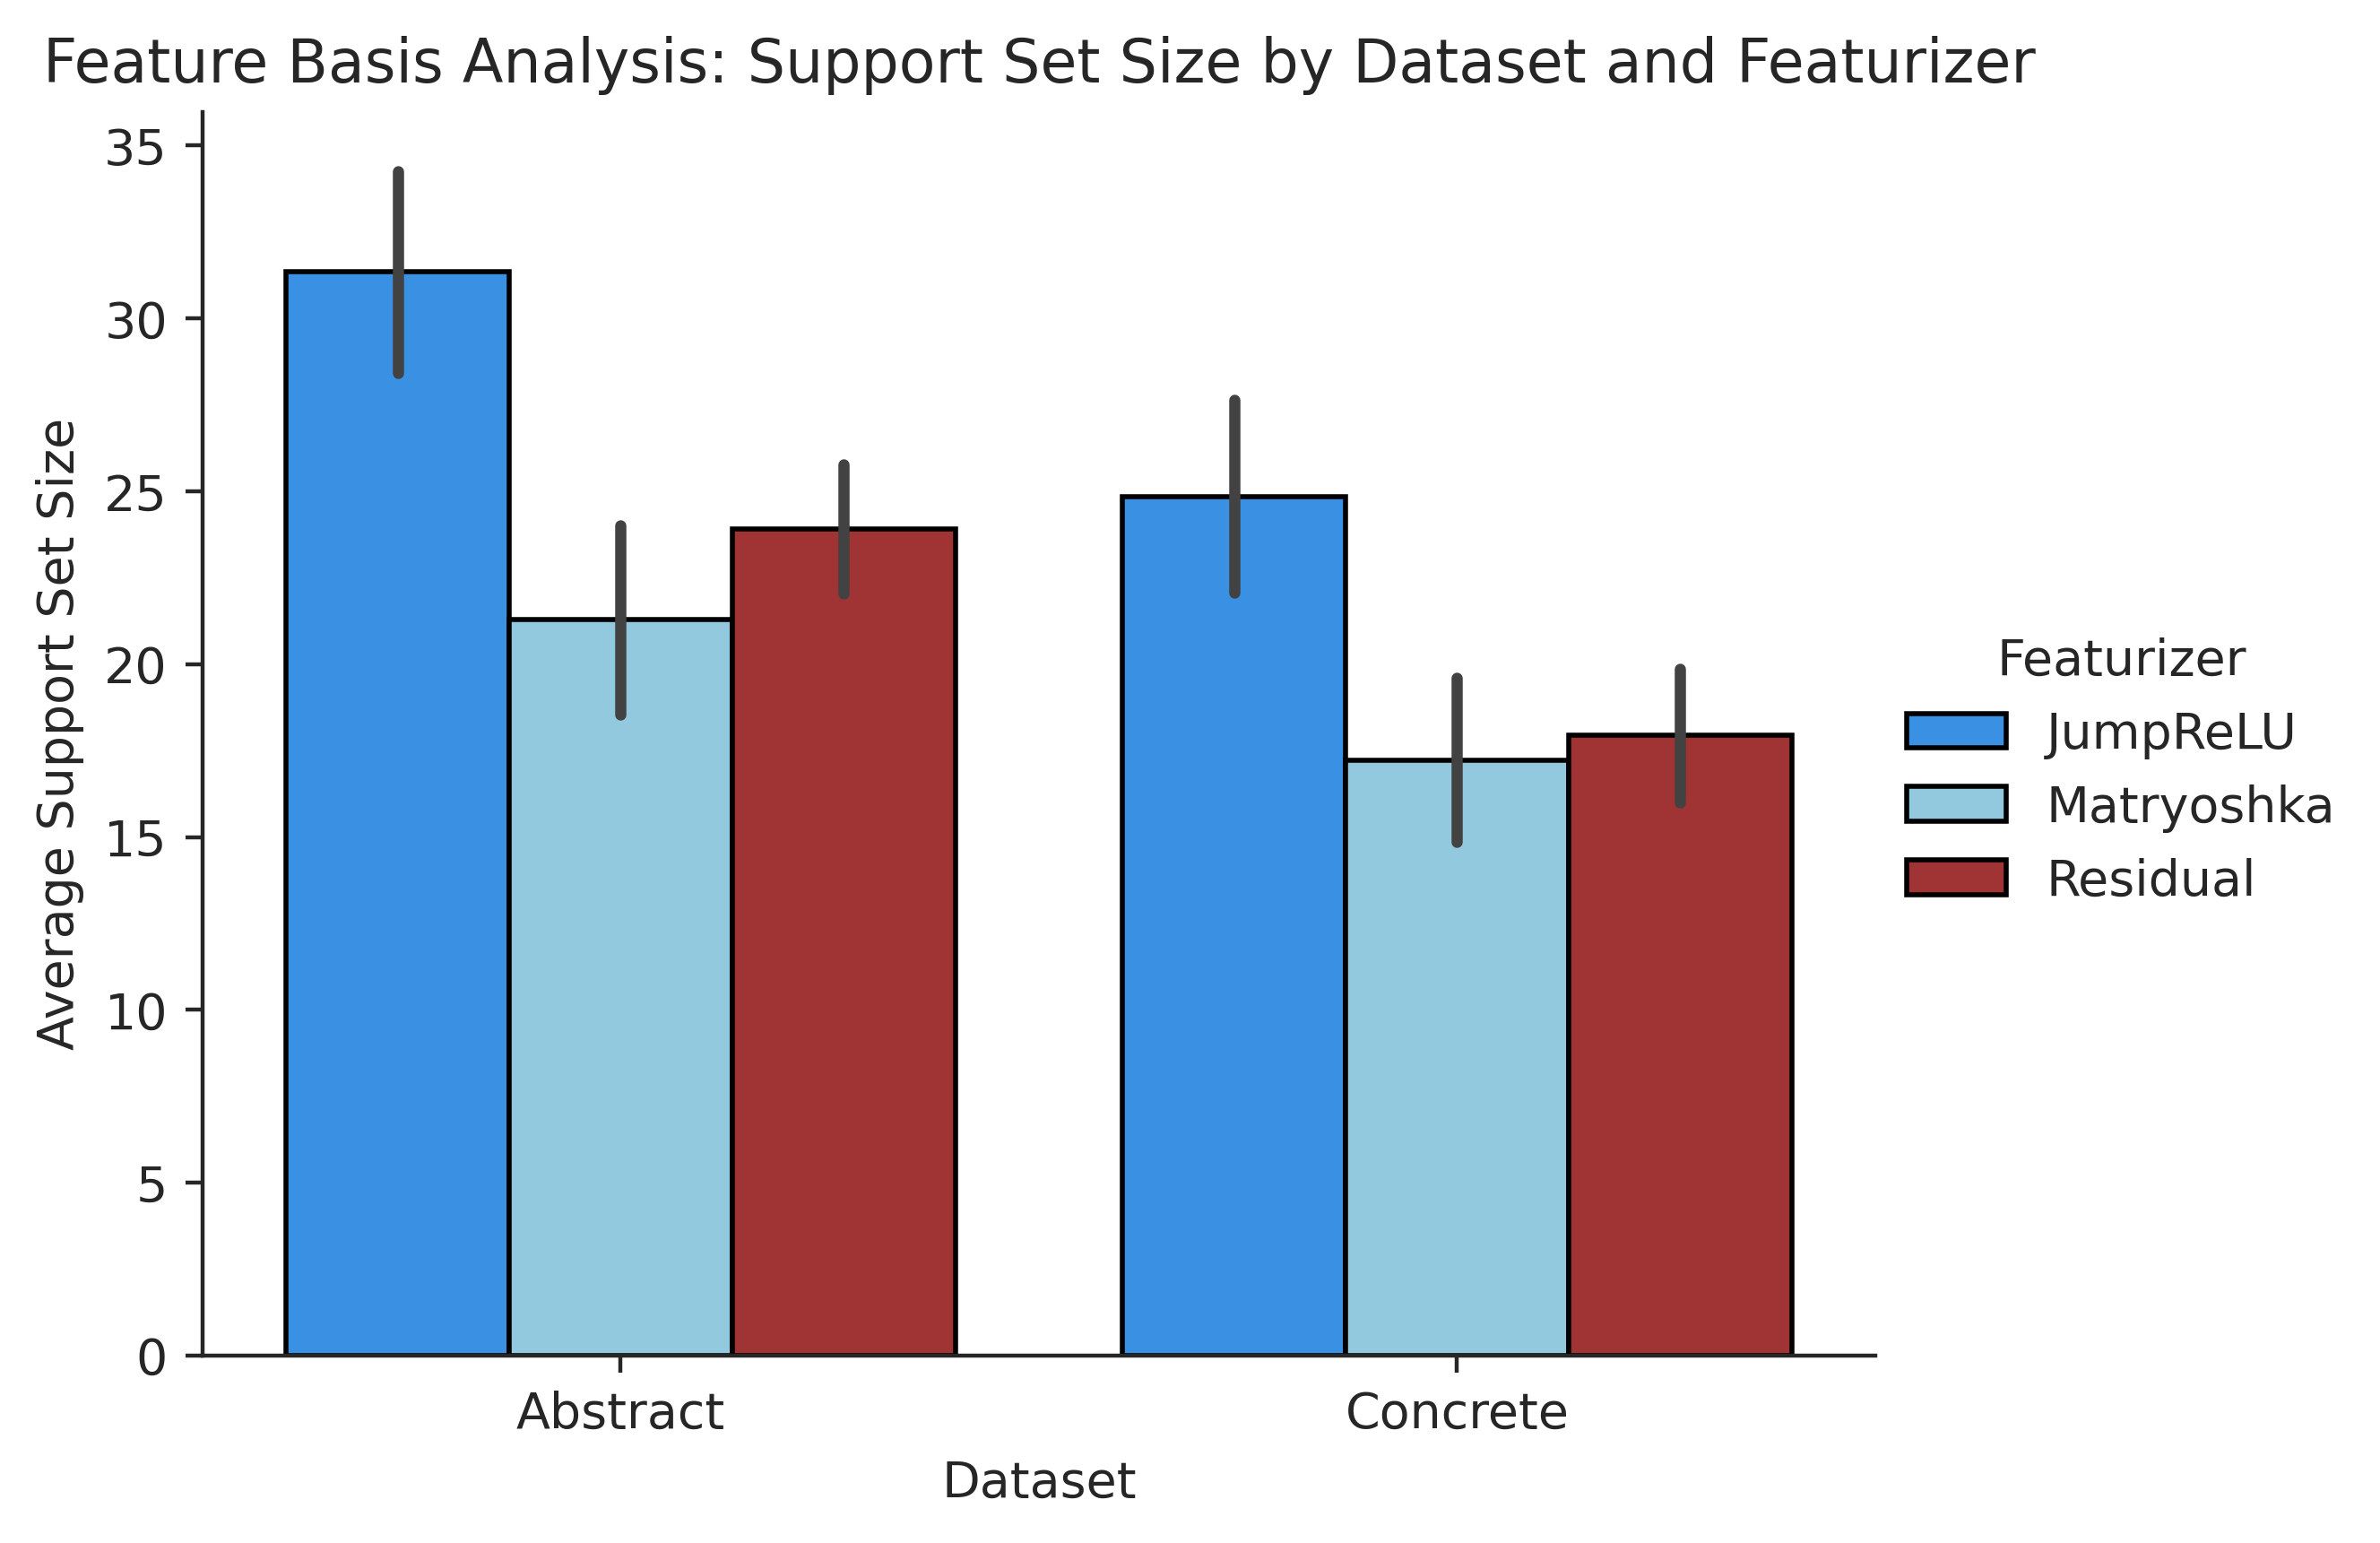

In [2]:
fig = regression_utils.feature_basis_plot()
fig.savefig("figures/preprint/study1_appendix_support_set_size.pdf", bbox_inches="tight")

## Appendix: Replicate Categories Results with Layer 14

In [9]:
significance = helpers.compute_significance_from_logprob(layer=14)
annotations = {}
for (dataset, feat), res in significance.items():
    annotations[(dataset, feat)] = helpers.p_to_stars(res['p_adj'])

/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Participant", grouping, "Featurizer"], as_index=False)[ycol]
/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:217: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df_participant_level.pivot_table(


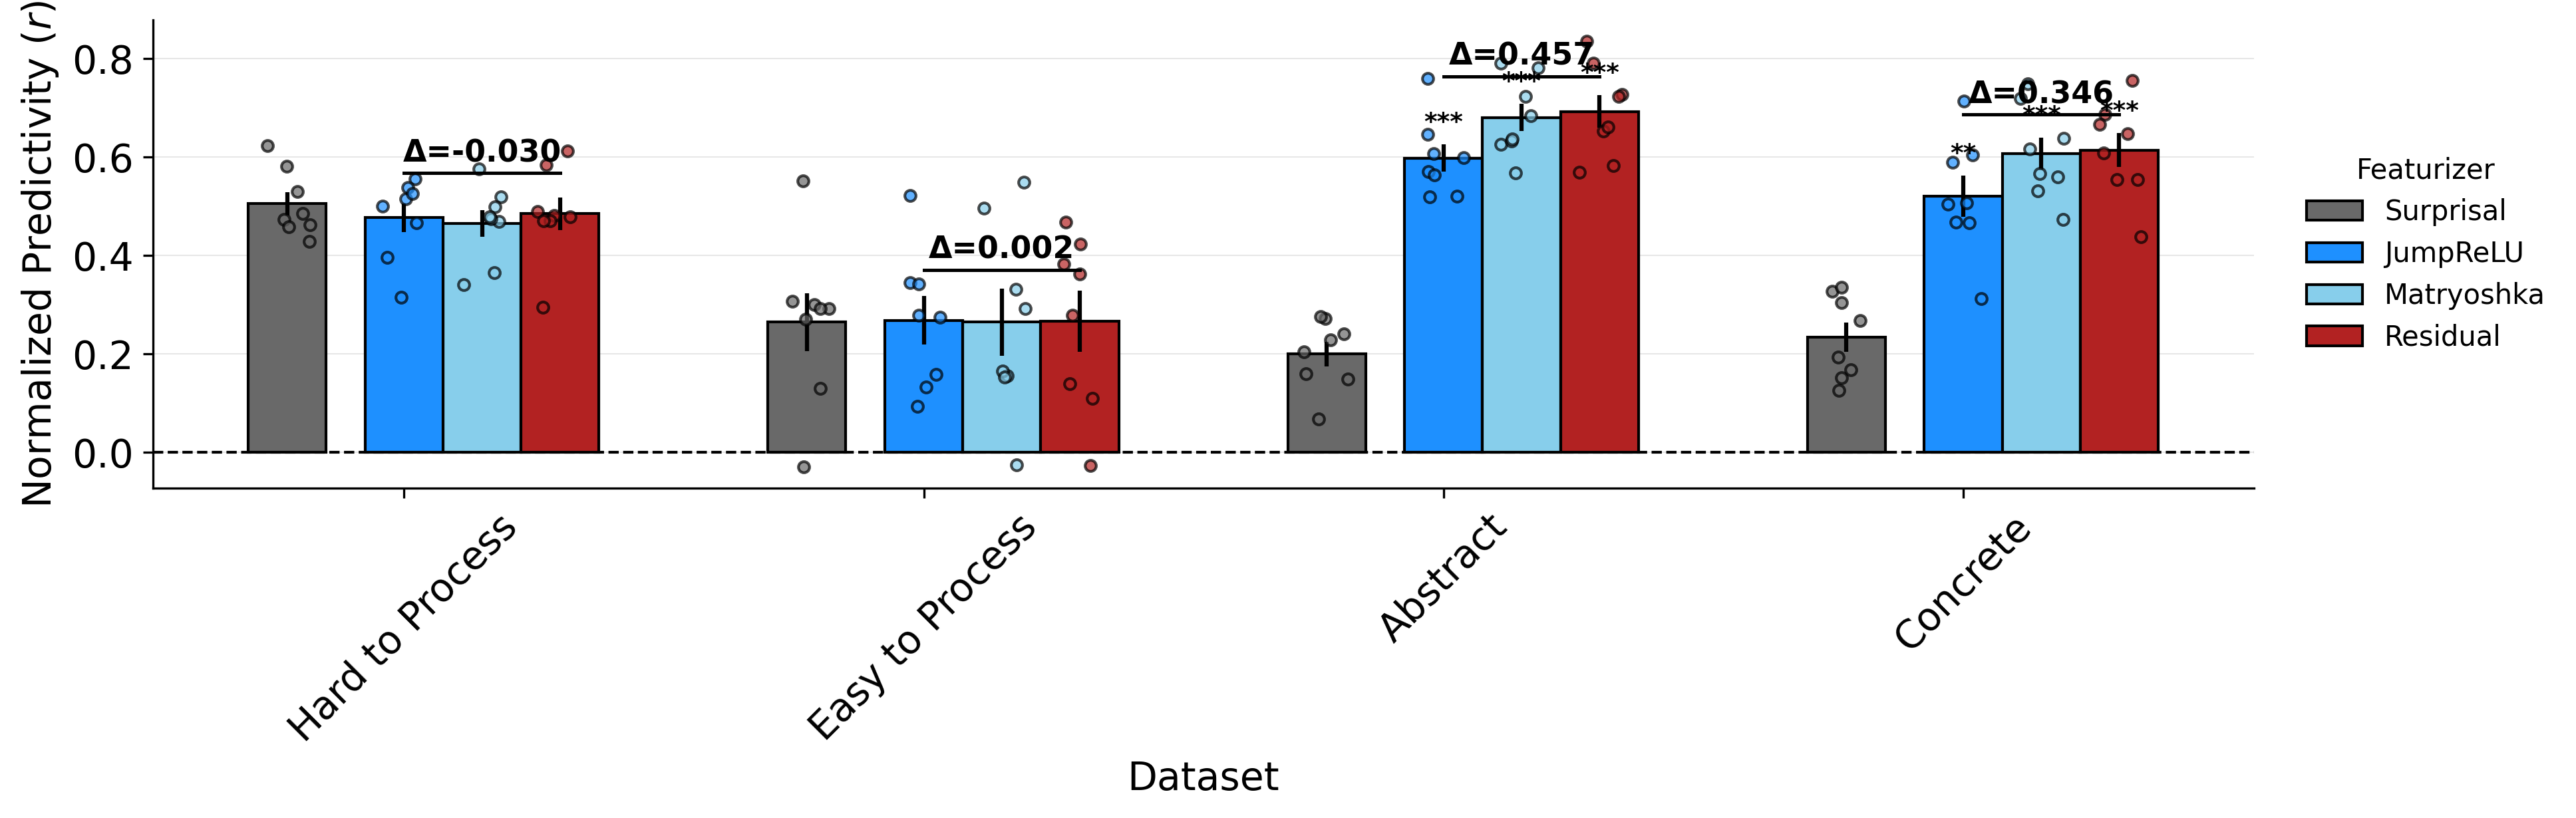

In [10]:
fig, ax = regression_utils.predictivity_bar_plot(add_significance=True, significance_annotations=annotations, filter_set=["Hard to Process", "Easy to Process", "Abstract", "Concrete"], layer=14, add_control=False)

fig.savefig("figures/preprint/study1_appendix_categories_barplot_layer14.pdf", bbox_inches="tight")

## Appendix: Categories Results without NC Normalization (Layer 12)

/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Participant", grouping, "Featurizer"], as_index=False)[ycol]
/Users/gretatuckute/Documents/GitHub/Neuroscope/analysis/helpers.py:217: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df_participant_level.pivot_table(


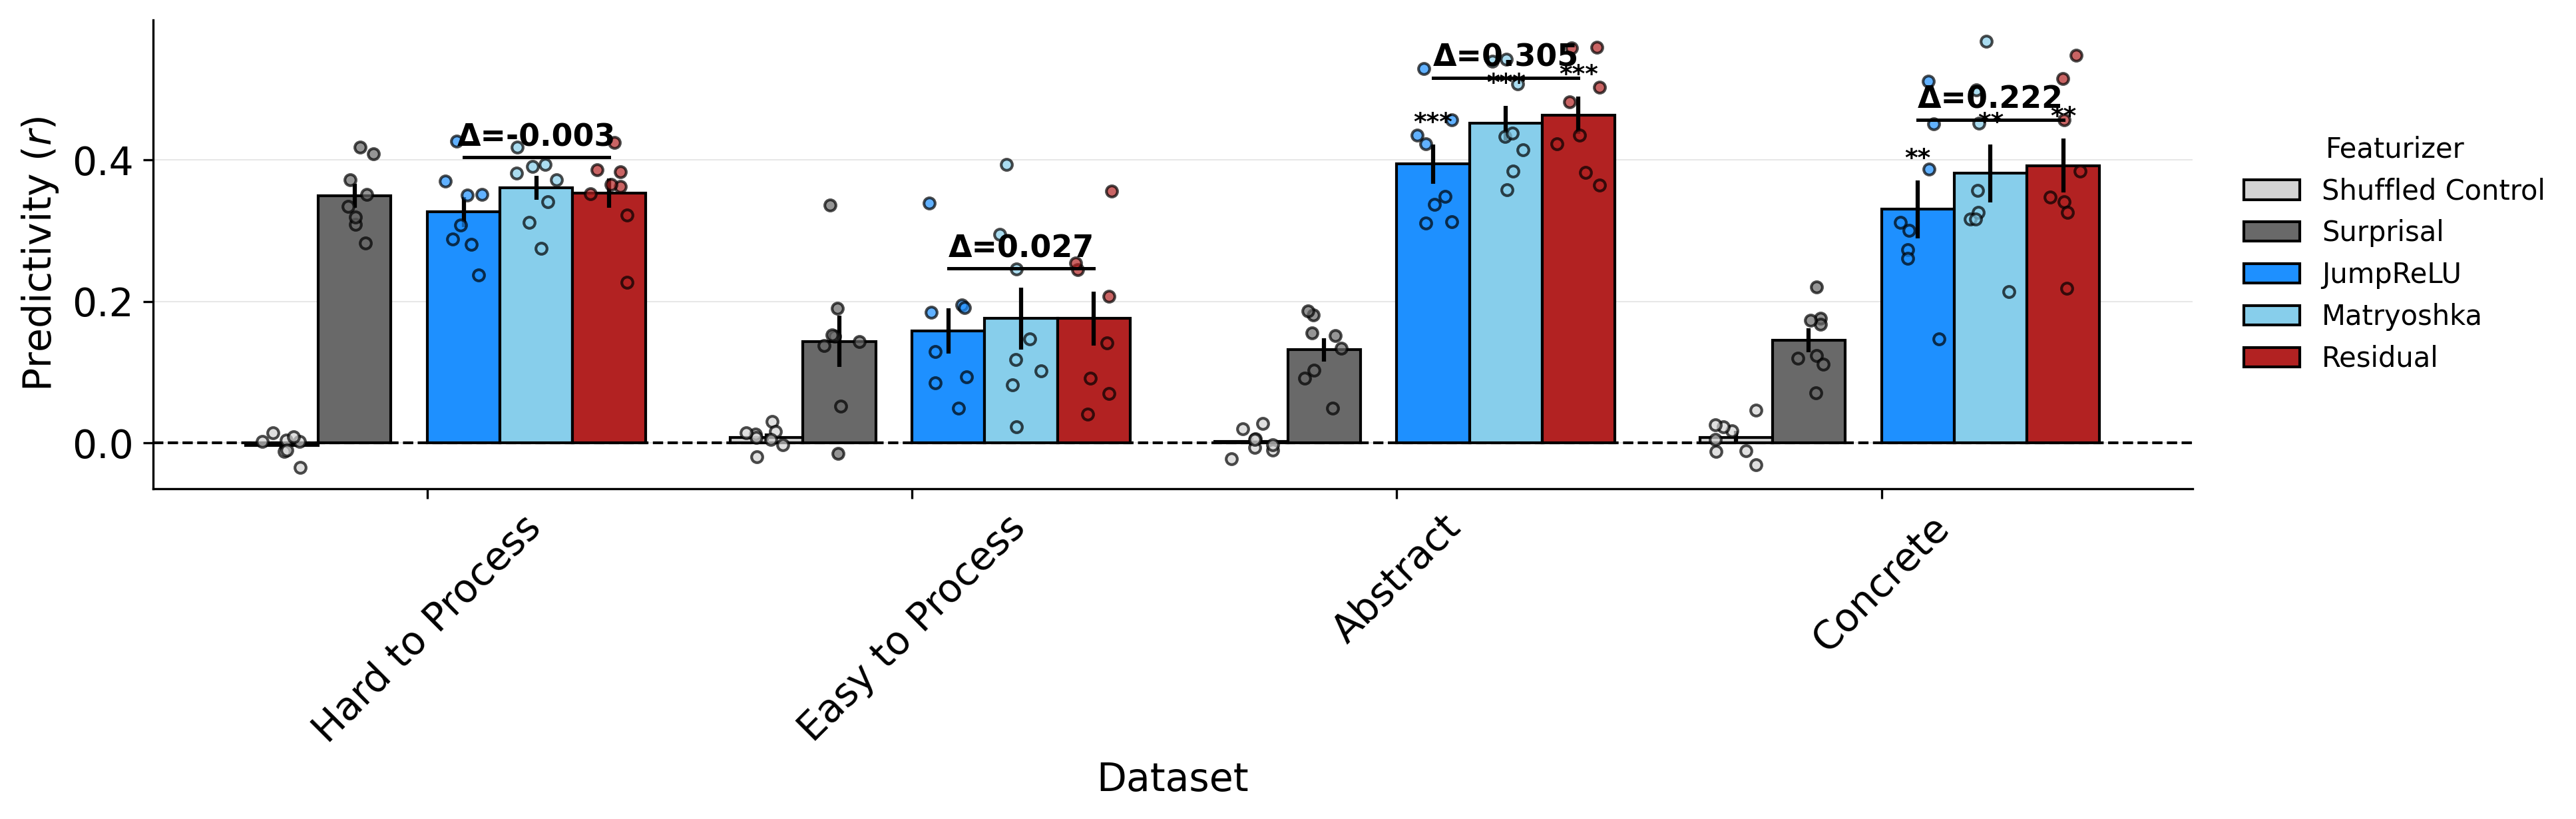

In [11]:
significance_raw = helpers.compute_significance_from_logprob(ycol="R Fischer")
annotations_raw = {}
for (dataset, feat), res in significance_raw.items():
    annotations_raw[(dataset, feat)] = helpers.p_to_stars(res['p_adj'])

fig, ax = regression_utils.predictivity_bar_plot(
    add_significance=True, significance_annotations=annotations_raw,
    filter_set=["Hard to Process", "Easy to Process", "Abstract", "Concrete"],
    ycol="R Fischer"
)
fig.savefig("figures/preprint/study1_appendix_categories_barplot_raw.pdf", bbox_inches="tight")